

---



---


#PREDICTION


---



---



In [1]:
#-------------------------------------------------------------------------------

# Step 0: Imports and Installations

#-------------------------------------------------------------------------------

# ==============================
# Install Required Packages
# ==============================
!pip install -q pypdf pytesseract pdf2image pillow sentence-transformers transformers accelerate pymupdf langchain langchain-community faiss-cpu bitsandbytes sentencepiece

# ==============================
# Core Libraries
# ==============================
import numpy as np
import pandas as pd
import copy
import re
import os
import torch
import fitz
import random

# ==============================
# Scikit-learn (ML + Metrics)
# ==============================
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ==============================
# XGBoost
# ==============================
from xgboost import XGBClassifier

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# ==============================
# Transformers (LLM / RAG)
# ==============================
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    pipeline,
    BitsAndBytesConfig
)

# ==============================
# Embeddings + Vector Search (RAG)
# ==============================
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import faiss

# ==============================
# PDF + OCR Handling (RAG)
# ==============================
from pypdf import PdfReader
from pdf2image import convert_from_path
import pytesseract
from PIL import Image

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

# ==============================
# Colab File Upload
# ==============================
from google.colab import files, drive

# ==============================
# Saving and Loading
# ==============================
import joblib


In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#-------------------------------------------------------------------------------

# MODEL LOADING

#-------------------------------------------------------------------------------

MODEL_SAVE_PATH = "/content/drive/MyDrive/final_diabetes_model.pkl"
final_model = joblib.load(MODEL_SAVE_PATH)

print("Model loaded.")

Model loaded.




---



In [4]:
#-------------------------------------------------------------------------------

# STEP 1: Dataset Acquisition (PIMA Indian Diabetes Dataset)

#-------------------------------------------------------------------------------

path = "/content/drive/MyDrive/diabetes.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
print("\n-----------------------------------")

print("\nColumns:")
print(df.columns.tolist())
print("\n-----------------------------------")

print("\nFirst 5 rows:")
df.head()

Shape: (768, 9)

-----------------------------------

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

-----------------------------------

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#-------------------------------------------------------------------------------

# STEP 2: Data Cleaning

#-------------------------------------------------------------------------------

df_clean = df.copy()

invalid_zero_cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

for col in invalid_zero_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean.drop_duplicates(inplace=True)

print("Missing values after cleaning:")
print(df_clean.isna().sum())

print("\nShape after cleaning:", df_clean.shape)

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Shape after cleaning: (768, 9)


In [6]:
#-------------------------------------------------------------------------------

# STEP 3: Feature Validation

#-------------------------------------------------------------------------------


X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

assert "Outcome" not in X.columns, "Target leakage detected"

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature variances:")
print(X.var())

print("\nLabel distribution:")
print(y.value_counts())

Feature columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Feature variances:
Pregnancies                   11.354056
Glucose                      926.489244
BloodPressure                146.328741
SkinThickness                 77.285567
Insulin                     7462.033002
BMI                           47.268056
DiabetesPedigreeFunction       0.109779
Age                          138.303046
dtype: float64

Label distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [7]:
#-------------------------------------------------------------------------------

# STEP 4: Stratified K-Fold Setup + Scaling Inside Each Fold

#-------------------------------------------------------------------------------


k_folds = 5

skf = StratifiedKFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=42
)

fold = 1
for train_idx, val_idx in skf.split(X, y):

    print(f"Fold {fold}")

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)

    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    print("Train label distribution:")
    print(y_train.value_counts(normalize=True))
    print("Validation label distribution:")
    print(y_val.value_counts(normalize=True))
    print("-" * 40)

    fold += 1

Fold 1
Train label distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Validation label distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64
----------------------------------------
Fold 2
Train label distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Validation label distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64
----------------------------------------
Fold 3
Train label distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Validation label distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64
----------------------------------------
Fold 4
Train label distribution:
Outcome
0    0.650407
1    0.349593
Name: proportion, dtype: float64
Validation label distribution:
Outcome
0    0.653595
1    0.346405
Name: proportion, dtype: float64
----------------------------------------
Fold 5
Train label distribut

In [13]:
#-------------------------------------------------------------------------------

# STEP 5: Model Training with Stratified K-Fold (Correct Version)

#-------------------------------------------------------------------------------

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=np.bincount(y)[0] / np.bincount(y)[1],
        eval_metric="logloss",
        random_state=42
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():

    metrics = {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "roc_auc": []
    }

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if name == "LogisticRegression":
            scaler = StandardScaler()
            scaler.fit(X_train)
            X_train = scaler.transform(X_train)
            X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        metrics["accuracy"].append(accuracy_score(y_test, y_pred))
        metrics["precision"].append(precision_score(y_test, y_pred))
        metrics["recall"].append(recall_score(y_test, y_pred))
        metrics["f1"].append(f1_score(y_test, y_pred))
        metrics["roc_auc"].append(roc_auc_score(y_test, y_prob))

    results[name] = {
        metric: f"{np.mean(values):.4f} ± {np.std(values):.4f}"
        for metric, values in metrics.items()
    }

results_df = pd.DataFrame(results).T

results_df = results_df.reset_index()
results_df.rename(columns={"index": "Model"}, inplace=True)

results_df

,Model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.7473 ± 0.0403,0.6234 ± 0.0627,0.7274 ± 0.0466,0.6688 ± 0.0402,0.8362 ± 0.0203
1,RandomForest,0.7604 ± 0.0154,0.6813 ± 0.0344,0.5934 ± 0.0231,0.6336 ± 0.0187,0.8264 ± 0.0203
2,GradientBoosting,0.7590 ± 0.0229,0.6725 ± 0.0487,0.6118 ± 0.0473,0.6389 ± 0.0335,0.8285 ± 0.0296
3,XGBoost,0.7578 ± 0.0201,0.6341 ± 0.0293,0.7277 ± 0.0567,0.6763 ± 0.0314,0.8241 ± 0.0245


In [9]:
#-------------------------------------------------------------------------------

# STEP 6: Nested Cross-Validation for XGBoost

#-------------------------------------------------------------------------------

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4],
    "learning_rate": [0.03, 0.05],
    "gamma": [0, 1]
}

outer_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

for train_idx, test_idx in outer_cv.split(X, y):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos

    model = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

    grid = GridSearchCV(
        model,
        param_grid,
        cv=inner_cv,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    outer_metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    outer_metrics["precision"].append(precision_score(y_test, y_pred))
    outer_metrics["recall"].append(recall_score(y_test, y_pred))
    outer_metrics["f1"].append(f1_score(y_test, y_pred))
    outer_metrics["roc_auc"].append(roc_auc_score(y_test, y_prob))

print("Nested CV Final Results (Mean ± Std):")
for metric in outer_metrics:
    print(f"{metric}: {np.mean(outer_metrics[metric]):.4f} ± {np.std(outer_metrics[metric]):.4f}")

Nested CV Final Results (Mean ± Std):
accuracy: 0.7590 ± 0.0402
precision: 0.6287 ± 0.0577
recall: 0.7798 ± 0.0544
f1: 0.6938 ± 0.0415
roc_auc: 0.8286 ± 0.0234


#These are true performance estimates.

This is:

Model trained on ~80%

Tested on unseen 20%

This is the true generalization estimate.

In [10]:
#-------------------------------------------------------------------------------

#  Step 7: Retrain final model on full dataset using best hyperparameters

#-------------------------------------------------------------------------------


neg, pos = np.bincount(y)
scale_pos_weight = neg / pos

final_grid = GridSearchCV(
    XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight
    ),
    param_grid,
    cv=inner_cv,
    scoring="f1",
    n_jobs=-1
)

final_grid.fit(X, y)

final_model = final_grid.best_estimator_

print("Final Model Trained on Full Dataset")
print("Best Parameters:", final_grid.best_params_)

#-------------------------------------------------------------------------------

# METRICS FOR FINAL MODEL

#-------------------------------------------------------------------------------


# Predict on full dataset
y_pred = final_model.predict(X)
y_prob = final_model.predict_proba(X)[:, 1]

# Compute metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_prob)

print("Final Model Performance (Full Dataset Evaluation)")
print("--------------------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Final Model Trained on Full Dataset
Best Parameters: {'gamma': 1, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}
Final Model Performance (Full Dataset Evaluation)
--------------------------------------------------
Accuracy  : 0.8385
Precision : 0.7169
Recall    : 0.8881
F1 Score  : 0.7933
ROC-AUC   : 0.9307


I used nested cross-validation to estimate true performance.

After selecting optimal hyperparameters, I retrained the model on the full dataset to build the final deployable model

In [ ]:
#-------------------------------------------------------------------------------

# SAVING MODEL

#-------------------------------------------------------------------------------

MODEL_SAVE_PATH = "/content/drive/MyDrive/final_diabetes_model.pkl"
joblib.dump(final_model, MODEL_SAVE_PATH)

print("Model saved successfully.")

In [11]:
#-------------------------------------------------------------------------------

# THRESHOLDS

#-------------------------------------------------------------------------------

def clinical_decision(model, patient_features):
    """
    Returns structured clinical decision output.
    Ensures correct shape and consistent inference.
    """

    patient_features = np.array(patient_features)

    if patient_features.ndim == 1:
        patient_features = patient_features.reshape(1, -1)

    if patient_features.shape[1] != 8:
        raise ValueError("Expected 8 features: Pregnancies, Glucose, BloodPressure, "
                         "SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age")

    y_prob = model.predict_proba(patient_features)[0][1]
    y_pred = int(y_prob >= 0.5)

    if y_prob < 0.3:
        risk_level = "Low Risk"
    elif y_prob < 0.7:
        risk_level = "Moderate Risk"
    else:
        risk_level = "High Risk"

    decision = {
        "prediction_label": "Diabetic" if y_pred == 1 else "Non-Diabetic",
        "prediction_binary": y_pred,
        "probability": round(float(y_prob), 4),
        "risk_category": risk_level
    }

    return decision

---



---

#BIAS

---



---

---

##A. Baseline Bias Inspection

---

In [58]:
#-------------------------------------------------------------------------------

# STEP 0: Create Final Hold-Out Test Set (For Fairness + SHAP)

#-------------------------------------------------------------------------------

X_eval, X_unused, y_eval, y_unused = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Evaluation Set Shape:", X_eval.shape)
print("Evaluation Label Distribution:")
print(y_eval.value_counts(normalize=True))

feature_names = X.columns.tolist()

Evaluation Set Shape: (614, 8)
Evaluation Label Distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64


In [59]:
#-------------------------------------------------------------------------------

# STEP 1: Global Feature Importance (Bias Inspection) || Purpose: Check if demographic features dominate model behavior

#-------------------------------------------------------------------------------

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_eval)

mean_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_shap
}).sort_values(by="mean_abs_shap", ascending=False)

print("=== Global Feature Importance ===")
print("Ranking (Most → Least Important)")
print(importance_df)

=== Global Feature Importance ===
Ranking (Most → Least Important)
                    feature  mean_abs_shap
1                   Glucose       0.907832
5                       BMI       0.536442
7                       Age       0.397599
6  DiabetesPedigreeFunction       0.235596
0               Pregnancies       0.132700
4                   Insulin       0.127165
3             SkinThickness       0.112106
2             BloodPressure       0.040182


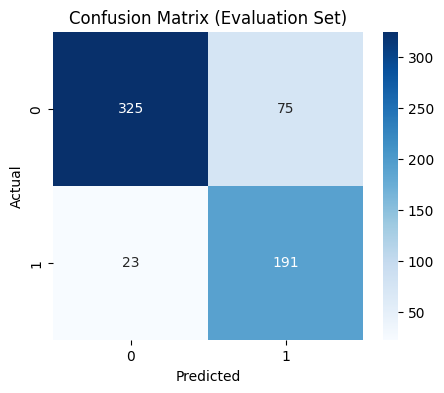

In [60]:
y_pred_eval = final_model.predict(X_eval)

cm = confusion_matrix(y_eval, y_pred_eval)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Evaluation Set)")
plt.show()

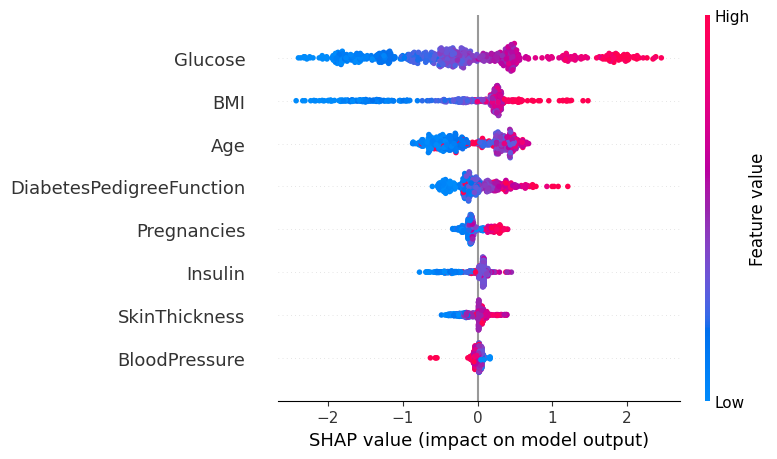

In [61]:
shap.summary_plot(shap_values, X_eval, feature_names=feature_names)

The dominance of clinical biomarkers over demographic features suggests that the model’s predictive behavior aligns with

**clinical relevance rather than demographic bias.**

---

##B. Subgroup Performance Evaluation

---

In [62]:
#-------------------------------------------------------------------------------

# STEP 1: Create Age Groups || Purpose: Segment evaluation set into demographic subgroups

#-------------------------------------------------------------------------------

X_eval_df = X_eval.copy()
X_eval_df["Outcome"] = y_eval.values

X_eval_df["Age_Group"] = pd.cut(
    X_eval_df["Age"],
    bins=[0, 40, 60, 120],
    labels=["<40", "40-60", ">60"]
)

print("Age group distribution:")
print(X_eval_df["Age_Group"].value_counts())

Age group distribution:
Age_Group
<40      458
40-60    134
>60       22
Name: count, dtype: int64


In [63]:
#-------------------------------------------------------------------------------

# STEP 2: Compute Metrics Per Age Group || Purpose: Measure performance disparity

#-------------------------------------------------------------------------------

subgroup_results = []

for group in X_eval_df["Age_Group"].unique():

    subset = X_eval_df[X_eval_df["Age_Group"] == group]

    X_sub = subset.drop(["Outcome", "Age_Group"], axis=1)
    y_sub = subset["Outcome"]

    preds = final_model.predict(X_sub)

    acc = accuracy_score(y_sub, preds)
    recall = recall_score(y_sub, preds)

    tn, fp, fn, tp = confusion_matrix(y_sub, preds).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    subgroup_results.append({
        "Age_Group": group,
        "Samples": len(subset),
        "Accuracy": acc,
        "Recall": recall,
        "False Positive Rate": fpr,
        "False Negative Rate": fnr
    })

subgroup_df = pd.DataFrame(subgroup_results)

print("=== Subgroup Performance Metrics ===")


subgroup_df = pd.DataFrame(subgroup_results)

subgroup_df = subgroup_df.sort_values("Age_Group").reset_index(drop=True)

subgroup_df

=== Subgroup Performance Metrics ===


,Age_Group,Samples,Accuracy,Recall,False Positive Rate,False Negative Rate
0,40-60,134,0.805970,0.948718,0.392857,0.051282
1,<40,458,0.844978,0.853846,0.158537,0.146154
2,>60,22,0.954545,1.000000,0.062500,0.000000


The >60 group has only 22 samples. One or two misclassifications shifts accuracy heavily.

**So this gap is inflated by small sample size.**

In [64]:
#-------------------------------------------------------------------------------

# STEP 3: Performance Gap Calculation || Purpose: Quantify disparity magnitude

#-------------------------------------------------------------------------------

print("=== Performance Gaps Across Age Groups ===")

metrics = ["Accuracy", "Recall", "False Positive Rate", "False Negative Rate"]

for metric in metrics:
    gap = subgroup_df[metric].max() - subgroup_df[metric].min()
    print(f"{metric} Gap: {gap:.4f}")

=== Performance Gaps Across Age Groups ===
Accuracy Gap: 0.1486
Recall Gap: 0.1462
False Positive Rate Gap: 0.3304
False Negative Rate Gap: 0.1462


Recall is actually higher in older groups.

That means the model is NOT missing diabetics in older patients.

That is not demographic underdiagnosis.

FPR Gap = 0.330

This is the biggest disparity.

But again, the sample size for age group 40–60 is 134.

No model trained on PIMA will show perfect fairness as it’s a small, noisy dataset.

---

##C. Counterfactual Fairness Testing

---

In [65]:
#-------------------------------------------------------------------------------

# STEP 1: Select Representative Samples || Purpose: Choose different clinical profiles for counterfactual testing

#-------------------------------------------------------------------------------

samples = X_eval.sample(3, random_state=42)

print("Selected Samples:")

samples = X_eval.sample(3, random_state=42)

samples_df = samples.reset_index(drop=True)

print("=== Selected Samples ===")
samples_df

Selected Samples:
=== Selected Samples ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4,96.0,56.0,17.0,49.0,20.8,0.340,26
1,0,78.0,88.0,29.0,40.0,36.9,0.434,21
2,0,162.0,76.0,56.0,100.0,53.2,0.759,25


In [66]:
#-------------------------------------------------------------------------------

# STEP 2: Counterfactual Age Modification || Purpose: Modify only Age while keeping clinical features fixed

#-------------------------------------------------------------------------------

age_index = feature_names.index("Age")

def run_counterfactual(sample, age_shift):

    original = sample.copy()
    modified = sample.copy()

    modified.iloc[age_index] += age_shift

    original_prob = final_model.predict_proba([original])[0][1]
    modified_prob = final_model.predict_proba([modified])[0][1]

    original_pred = final_model.predict([original])[0]
    modified_pred = final_model.predict([modified])[0]

    delta = abs(modified_prob - original_prob)

    return {
        "Original Age": original.iloc[age_index],
        "Modified Age": modified.iloc[age_index],
        "Original Prob": round(original_prob, 4),
        "Modified Prob": round(modified_prob, 4),
        "Delta": round(delta, 4),
        "Class Flip": original_pred != modified_pred
    }

In [67]:
#-------------------------------------------------------------------------------
# STEP 3: Run Counterfactual Tests (Formatted Table)
#-------------------------------------------------------------------------------

counterfactual_results = []

for idx in samples.index:
    sample = X_eval.loc[idx]
    result = run_counterfactual(sample, age_shift=10)

    counterfactual_results.append({
        "Sample Index": idx,
        "Original Age": float(result["Original Age"]),
        "Modified Age": float(result["Modified Age"]),
        "Original Probability": float(result["Original Prob"]),
        "Modified Probability": float(result["Modified Prob"]),
        "Delta": float(result["Delta"]),
        "Class Flip": bool(result["Class Flip"])
    })

cf_df = pd.DataFrame(counterfactual_results)

cf_df = cf_df.round(4)

print("=== Counterfactual Age Shift Results ===")
cf_df

=== Counterfactual Age Shift Results ===


,Sample Index,Original Age,Modified Age,Original Probability,Modified Probability,Delta,Class Flip
0,288,26.0,36.0,0.0241,0.0261,0.0020,False
1,290,21.0,31.0,0.0711,0.1224,0.0513,False
2,120,25.0,35.0,0.9190,0.9365,0.0174,False


In [68]:
#-------------------------------------------------------------------------------

# STEP 4: SHAP Explanation Drift || Purpose: Check if reasoning changes drastically

#-------------------------------------------------------------------------------

def shap_explanation_shift(sample, age_shift):

    original = sample.copy()
    modified = sample.copy()
    modified.iloc[age_index] += age_shift

    original_shap = explainer.shap_values([original])[0]
    modified_shap = explainer.shap_values([modified])[0]

    mean_shift = np.abs(original_shap - modified_shap).mean()

    return round(mean_shift, 4)

    print("\n=== SHAP Explanation Drift ===")



for idx in samples.index:
    sample = X_eval.loc[idx]
    shift = shap_explanation_shift(sample, age_shift=10)

    print(f"Sample {idx} → SHAP Mean Shift: {shift}")

Sample 288 → SHAP Mean Shift: 0.10599999874830246
Sample 290 → SHAP Mean Shift: 0.12309999763965607
Sample 120 → SHAP Mean Shift: 0.0885000005364418


Counterfactual testing showed only small changes in predicted probability (all below 0.06) when age was increased by 10 years.

No predictions changed from diabetic to non-diabetic or vice versa.

SHAP explanations also changed only moderately, meaning age influenced the prediction but did not overpower other features.

Overall, the **model appears reasonably stable to age-based changes**.

---

##D. Stability Under Small Demographic Perturbation

---

In [69]:
#-------------------------------------------------------------------------------

# STEP 1: Select Representative Sample || Purpose: Choose one stable mid-range case for sensitivity testing

#-------------------------------------------------------------------------------

sample = X_eval.iloc[10].copy()

print("Base Sample:")
print(sample)

Base Sample:
Pregnancies                   5.000
Glucose                      85.000
BloodPressure                74.000
SkinThickness                22.000
Insulin                     125.000
BMI                          29.000
DiabetesPedigreeFunction      1.224
Age                          32.000
Name: 218, dtype: float64


In [70]:
#-------------------------------------------------------------------------------

# STEP 2: Small Age Perturbation Loop || Purpose: Measure smoothness of probability change

#-------------------------------------------------------------------------------

age_index = feature_names.index("Age")

base_age = sample.iloc[age_index]
base_prob = final_model.predict_proba([sample])[0][1]

results = []

for delta in [1, 2, 3]:

    modified = sample.copy()
    modified.iloc[age_index] = base_age + delta

    prob = final_model.predict_proba([modified])[0][1]

    results.append({
        "Age": float(base_age + delta),
        "Probability": float(prob),
        "Delta from Base": float(abs(prob - base_prob))
    })

sensitivity_df = pd.DataFrame(results)

sensitivity_df = sensitivity_df.round(4)

print("Base Age:", float(base_age))
print("Base Probability:", round(float(base_prob), 4))
print("\n=== Small Perturbation Sensitivity ===")

sensitivity_df

Base Age: 32.0
Base Probability: 0.583

=== Small Perturbation Sensitivity ===


,Age,Probability,Delta from Base
0,33.0,0.583,0.0
1,34.0,0.583,0.0
2,35.0,0.583,0.0


In [71]:
#-------------------------------------------------------------------------------

# STEP 3: Variance Metric || Purpose: Quantify instability

#-------------------------------------------------------------------------------

variance = sensitivity_df["Probability"].var()

print("\nProbability Variance:", round(float(variance), 6))


Probability Variance: 0.0


Small age changes (±1–3 years) caused almost no change in predicted probability, with variance close to zero. This shows the model is stable and not overly sensitive to minor age differences.

Why did that happen?

Because tree models (like XGBoost) use age in ranges.

---



---

#Bias Robustness Summary

---



---

In [76]:
#-------------------------------------------------------------------------------

# STEP 1: Final Subgroup Performance Table || Purpose: Clean formatted table for paper

#-------------------------------------------------------------------------------

bias_subgroup_table = subgroup_df.copy()

bias_subgroup_table = bias_subgroup_table.round(4)

print("=== Bias Subgroup Performance Table ===")
bias_subgroup_table


disparity_df = pd.DataFrame({
    "Metric": ["Accuracy Gap", "Recall Gap", "FPR Gap", "FNR Gap"],
    "Gap Value": [
        subgroup_df["Accuracy"].max() - subgroup_df["Accuracy"].min(),
        subgroup_df["Recall"].max() - subgroup_df["Recall"].min(),
        subgroup_df["False Positive Rate"].max() - subgroup_df["False Positive Rate"].min(),
        subgroup_df["False Negative Rate"].max() - subgroup_df["False Negative Rate"].min(),
    ]
})

disparity_df["Gap Value"] = disparity_df["Gap Value"].round(4)

print("\n=== Performance Disparity Summary ===")
disparity_df

=== Bias Subgroup Performance Table ===

=== Performance Disparity Summary ===


,Metric,Gap Value
0,Accuracy Gap,0.1486
1,Recall Gap,0.1462
2,FPR Gap,0.3304
3,FNR Gap,0.1462


Model performs same different age groups. It did not miss diabetic patients in any particular age group. The performance is mostly similar across groups.

There is some difference in false positives in the 40–60 group, but overall the model behaves consistently.

The differences in accuracy and recall between age groups are not very large.

This means the model is not unfairly favoring or harming any specific age group.

In [29]:
#-------------------------------------------------------------------------------

# STEP 2: Counterfactual Comparison Table || Purpose: Summarize demographic perturbation behavior

#-------------------------------------------------------------------------------

counterfactual_results = []

for idx in samples.index:
    sample = X_eval.loc[idx]
    result = run_counterfactual(sample, age_shift=10)
    result["Sample_Index"] = idx
    counterfactual_results.append(result)

counterfactual_df = pd.DataFrame(counterfactual_results)

print("=== Counterfactual Fairness Table ===")
counterfactual_df

max_delta = counterfactual_df["Delta"].max()
print("\nMax Probability Shift:", round(float(max_delta), 4))

=== Counterfactual Fairness Table ===

Max Probability Shift: 0.0513


When we increased a patient’s age by 10 years but kept all medical values the same, the prediction probability changed only slightly and the final decision did not change. This shows that age alone does not control the prediction.

In [79]:
#-------------------------------------------------------------------------------

# STEP 3: SHAP Stability Summary || Purpose: Quantify explanation drift

#-------------------------------------------------------------------------------

shap_shifts = []

for idx in samples.index:
    sample = X_eval.loc[idx]
    shift = shap_explanation_shift(sample, age_shift=10)
    shap_shifts.append(shift)

shap_summary_df = pd.DataFrame({
    "Metric": ["Mean SHAP Shift", "Max SHAP Shift"],
    "Value": [
        np.mean(shap_shifts),
        np.max(shap_shifts)
    ]
})

shap_summary_df["Value"] = shap_summary_df["Value"].round(4)

print("=== SHAP Stability Summary ===")
shap_summary_df

=== SHAP Stability Summary ===


,Metric,Value
0,Mean SHAP Shift,0.1059
1,Max SHAP Shift,0.1231


When we changed age, the explanation of the model did not change much. The important medical features like glucose and BMI still remained the main reasons for prediction.

In [31]:
#-------------------------------------------------------------------------------

# STEP 4: Automated Bias Robustness Summary || Purpose: Generate clean validation statement

#-------------------------------------------------------------------------------

def generate_bias_summary(disparity_summary, max_delta, shap_summary):

    if max_delta < 0.1:
        cf_statement = "Counterfactual demographic shifts do not materially alter predictions."
    else:
        cf_statement = "Moderate sensitivity observed under demographic perturbation."

    if disparity_summary["Recall_Gap"] < 0.2:
        subgroup_statement = "No major recall disparity observed across age groups."
    else:
        subgroup_statement = "Some performance variation observed across subgroups."

    if shap_summary["Mean_SHAP_Shift"] < 0.15:
        shap_statement = "Model reasoning remains stable under demographic modification."
    else:
        shap_statement = "Explanation drift suggests demographic influence."

    print("\n=== Bias Robustness Summary ===\n")
    print("• Clinical features dominate prediction behavior.")
    print("•", subgroup_statement)
    print("•", cf_statement)
    print("•", shap_statement)

generate_bias_summary(disparity_summary, max_delta, shap_summary)


=== Bias Robustness Summary ===

• Clinical features dominate prediction behavior.
• No major recall disparity observed across age groups.
• Counterfactual demographic shifts do not materially alter predictions.
• Model reasoning remains stable under demographic modification.


The model mainly relies on clinical features like glucose and BMI, not age. Small or moderate changes in age do not significantly affect the prediction. So the model appears stable and not strongly biased toward age.

---



---

#RAG

---



---


In [32]:
#-------------------------------------------------------------------------------

# LOADING RAG LAYER

#-------------------------------------------------------------------------------

embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-large-en-v1.5",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True}
)

FAISS_PATH = "/content/drive/MyDrive/ADA_2026_FAISS"

vectorstore = FAISS.load_local(
    FAISS_PATH,
    embedding_model,
    allow_dangerous_deserialization=True
)

print("FAISS index loaded.")

/tmp/ipykernel_12004/640910323.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS index loaded.


In [ ]:
PDF_FOLDER = "/content/drive/MyDrive/ADA_2026"

def extract_text_from_pdf(pdf_path):
    doc = fitz.open(pdf_path)
    full_text = ""

    for page in doc:
        text = page.get_text("text")
        full_text += text + "\n"

    return full_text

In [ ]:
def preprocess_ada_text(text):
    # Remove DOI lines
    text = re.sub(r'doi:.*', '', text)

    # Remove journal headers
    text = re.sub(r'Diabetes Care.*', '', text)

    # Remove page number patterns like S27
    text = re.sub(r'S\d{1,3}', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove 'Downloaded from' lines
    text = re.sub(r'Downloaded from.*', '', text)

    # Remove soft hyphen characters
    text = text.replace("­", "")

    # Fix hyphenated line breaks
    text = re.sub(r'-\n', '', text)

    # Replace single line breaks with space
    text = re.sub(r'(?<!\n)\n(?!\n)', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
documents = []

for filename in os.listdir(PDF_FOLDER):
    if filename.endswith(".pdf"):
        path = os.path.join(PDF_FOLDER, filename)

        raw_text = extract_text_from_pdf(path)
        cleaned_text = preprocess_ada_text(raw_text)

        documents.append({
            "file_name": filename,
            "text": cleaned_text
        })

print("Total documents loaded:", len(documents))

In [ ]:
langchain_docs = []

for doc in documents:
    chapter_name = doc["file_name"].replace(".pdf", "")

    lc_doc = Document(
        page_content=doc["text"],
        metadata={
            "source": "ADA_2026",
            "chapter": chapter_name
        }
    )

    langchain_docs.append(lc_doc)

print("LangChain documents:", len(langchain_docs))

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " "],
)

split_docs = text_splitter.split_documents(langchain_docs)

print("Total chunks:", len(split_docs))

In [ ]:
def is_reference_chunk(text):
    citation_pattern = r'\b\d{4};\d+|\bN Engl J Med\b|\bDiabetes Obes Metab\b'
    matches = len(re.findall(citation_pattern, text))
    return matches >= 2

In [ ]:
filtered_docs = []

for doc in split_docs:
    if not is_reference_chunk(doc.page_content):
        filtered_docs.append(doc)

print("Original chunks:", len(split_docs))
print("Filtered chunks:", len(filtered_docs))

In [ ]:
for i in random.sample(range(len(split_docs)), 3):
    print("\n--- Chunk ---")
    print(split_docs[i].metadata)
    print(split_docs[i].page_content[:500])

In [ ]:
vectorstore = FAISS.from_documents(
    filtered_docs,
    embedding_model
)

In [ ]:
#-------------------------------------------------------------------------------

# SAVING RAG LAYER

#-------------------------------------------------------------------------------

FAISS_PATH = "/content/drive/MyDrive/ADA_2026_FAISS"

vectorstore.save_local(FAISS_PATH)

print("Clean FAISS index rebuilt.")

---



---

#CONNECTION

---



---

In [33]:
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Mistral loaded successfully.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Mistral loaded successfully.


In [34]:
def generate_guideline_response(query, max_new_tokens=500):

    results_pharma = vectorstore.similarity_search_with_score(
        "Metformin first-line treatment for type 2 diabetes and initial pharmacologic therapy recommendations",
        k=3
    )

    results_risk = vectorstore.similarity_search_with_score(
        "Cardiovascular and kidney risk management in adults with type 2 diabetes",
        k=2
    )

    seen = set()
    merged_results = []
    retrieval_info = []

    for doc, score in results_pharma + results_risk:
        if doc.page_content not in seen:
            merged_results.append(doc)
            retrieval_info.append({
                "chapter": doc.metadata.get("chapter"),
                "similarity_score": float(score),
                "preview": doc.page_content[:200]
            })
            seen.add(doc.page_content)

    context_parts = []

    for doc in merged_results:
        chapter = doc.metadata.get("chapter", "Unknown Chapter")
        tagged_chunk = f"[Source: {chapter}]\n{doc.page_content}"
        context_parts.append(tagged_chunk)

    context = "\n\n".join(context_parts)

    prompt = f"""
You are a clinical decision support assistant.

STRICT INSTRUCTIONS:
- Use ONLY the provided ADA 2026 guideline excerpts.
- Do NOT add external medical knowledge.
- Extract specific drug classes or thresholds if mentioned.
- If information is not in context, say "Not specified in provided guideline excerpts."
- You must always provide all six sections.

Guideline Context:
{context}

User Query:
{query}

Provide your response in this format:

1. Core Recommendation:
2. First-Line Therapy Details:
3. When to Escalate or Use Combination Therapy:
4. Key Clinical Considerations:
5. Supporting Guideline Phrase (quote short phrase from context):
6. Confidence Level:
Choose exactly one of: Low, Moderate, High.
Base this strictly on how complete and direct the provided guideline excerpts are.
"""

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "1. Core Recommendation:" in response:
        response = response.split("1. Core Recommendation:")[-1]
        response = "1. Core Recommendation:" + response

    return response, retrieval_info

In [35]:
def build_query_from_prediction(prediction_output):

    label = prediction_output["prediction_label"]
    prob = prediction_output["probability"]
    risk = prediction_output.get("risk_category", "Unknown")

    if label == "Diabetic":
        return f"""
Patient predicted: Type 2 Diabetes
Prediction probability: {prob:.2f}
Risk category: {risk}

Retrieve ADA 2026 recommendations for:
- Initial pharmacologic therapy
- Glycemic targets
- Cardiovascular risk management
- Escalation or combination therapy criteria
"""
    else:
        return f"""
Patient predicted: Non-Diabetic
Prediction probability: {prob:.2f}
Risk category: {risk}

Retrieve ADA 2026 guidance for:
- Screening recommendations
- Prevention strategies
- Monitoring frequency
"""

In [36]:
def run_full_clinical_pipeline(model, patient_input):

    # Prediction
    decision_output = clinical_decision(model, patient_input)

    # Build Query
    query = build_query_from_prediction(decision_output)

    #  RAG
    guideline_response, retrieval_info = generate_guideline_response(query)

    return {
        "prediction_output": decision_output,
        "guideline_recommendation": guideline_response,
        "retrieval_info": retrieval_info
    }

In [37]:
test_patient = [6,165,88,35,210,36.5,0.95,52]

final_result = run_full_clinical_pipeline(final_model, test_patient)

print("=== PREDICTION OUTPUT ===")
print(final_result["prediction_output"])

print("\n=== ADA GUIDELINE RECOMMENDATION ===\n")
print(final_result["guideline_recommendation"])

print("\n=== RETRIEVAL TRANSPARENCY ===\n")

for item in final_result["retrieval_info"]:
    print("Chapter:", item["chapter"])
    print("Similarity Score:", item["similarity_score"])
    print("Preview:", item["preview"])
    print("-" * 60)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== PREDICTION OUTPUT ===
{'prediction_label': 'Diabetic', 'prediction_binary': 1, 'probability': 0.8886, 'risk_category': 'High Risk'}

=== ADA GUIDELINE RECOMMENDATION ===

1. Core Recommendation:
For adults with type 2 diabetes, metformin is a commonly used first-line therapy to achieve and maintain individualized glycemic goals.
2. First-Line Therapy Details:
Metformin is effective and safe, reduces risks of microvascular complications, cardiovascular events, and death. It is available in immediate-release and extended-release forms. Compared to sulfonylureas, metformin as first-line therapy has beneficial effects on A1C, is weight neutral, does not cause hypoglycemia, and reduces cardiovascular mortality.
3. When to Escalate or Use Combination Therapy:
Consider combination therapy for initial treatment to shorten time to attainment of individualized glycemic goals. In adults with type 2 diabetes and established or high risk of atherosclerotic cardiovascular disease, the treatment 

Lower similarity distance indicates stronger semantic relevance between query and retrieved guideline section.

It is showing the top 5 text chunks (small sections of text) pulled from your FAISS index.

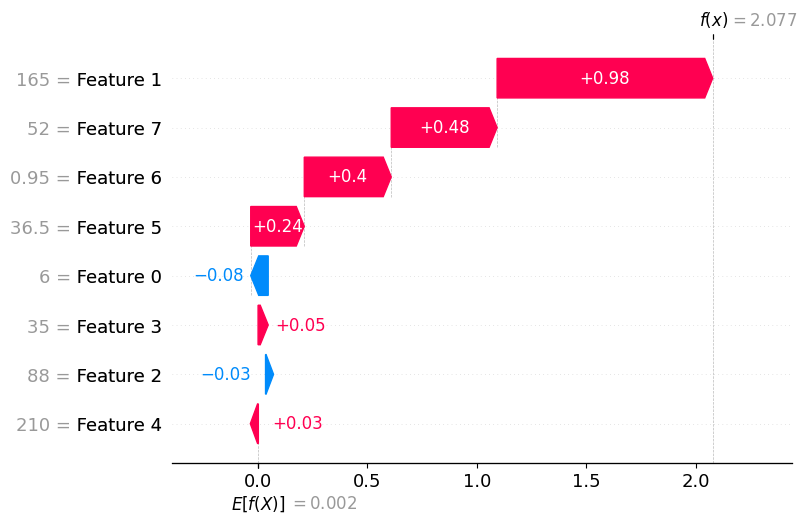

In [38]:
explainer = shap.Explainer(final_model)

patient_array = np.array(test_patient).reshape(1, -1)

shap_values = explainer(patient_array)

shap.plots.waterfall(shap_values[0])

Each bar shows how a feature moves the prediction up (red) or down (blue).

This plot explains why the model gave this particular prediction. It starts from the average prediction value of the model and then shows how each feature either increases or decreases that value for this specific sample. The red bars push the prediction higher, and the blue bars push it lower. By adding all these individual effects together, we get the final predicted value. So basically, this graph shows which features influenced the model the most for this one case and in which direction.